# Backpropagation and Training

This notebook demonstrates how the NumPy model actually *learns* from data using Gradient Descent and Backpropagation.

## Learning Objectives
- Understand Cross-Entropy Loss.
- Understand how gradients flow backward through the network (Chain Rule).
- Perform a lightweight training loop in isolation.

In [1]:
import sys
import pathlib

# Dynamically resolve project root
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: D:\project\DIGIT Recognition


## The Learning Process

1. **Forward Propagation**: Predict an output.
2. **Loss Calculation**: Measure how wrong the prediction is using Categorical Cross-Entropy: `L = -Σ y log(p)`
3. **Backpropagation**: Compute the gradient (derivative) of the loss with respect to every weight and bias using the Chain Rule.
4. **Gradient Descent**: Update weights: `W_new = W_old - η * dW` (where η is the learning rate).

In [2]:
from backend.app.model.network import NeuralNetwork
from backend.app.dataset.mnist_loader import load_mnist
import numpy as np
import matplotlib.pyplot as plt

# We initialize a BRAND NEW, isolated model. 
# We DO NOT load the production weights to avoid overwriting them.
model = NeuralNetwork(seed=42)

# Load a tiny subset (1000 samples) to train very quickly
X_train, y_train = load_mnist(split="train", subset_size=1000)

# Convert labels to one-hot encoding for training
num_samples = len(y_train)
y_one_hot = np.zeros((num_samples, 10))
y_one_hot[np.arange(num_samples), y_train] = 1

print(f"X_train shape: {X_train.shape}")
print(f"y_one_hot shape: {y_one_hot.shape}")

X_train shape: (1000, 784)
y_one_hot shape: (1000, 10)


## Lightweight Training Loop
Let's train for just 5 epochs to demonstrate learning.

In [3]:
epochs = 5
learning_rate = 0.1
batch_size = 32

history = {"loss": [], "acc": []}

for epoch in range(epochs):
    # Shuffle
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_one_hot[indices]
    y_labels = y_train[indices]
    
    epoch_loss = 0
    correct = 0
    
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 1. Forward Pass
        probs = model.forward(X_batch, training=True)
        
        # 2. Loss & Accuracy
        loss = model.loss_fn.forward(probs, y_batch)
        epoch_loss += loss * len(X_batch)
        preds = np.argmax(probs, axis=1)
        correct += np.sum(preds == y_labels[i:i+batch_size])
        
        # 3. Gradients & Backpropagation
        d_loss = model.loss_fn.backward()
        model.backward(d_loss)
        
        # 4. Weight Update
        model.update_weights(learning_rate)
        
    avg_loss = epoch_loss / num_samples
    avg_acc = correct / num_samples
    history["loss"].append(avg_loss)
    history["acc"].append(avg_acc)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {avg_acc:.4f}")

Epoch 1/5 - Loss: 1.4996 - Accuracy: 0.5360
Epoch 2/5 - Loss: 0.6391 - Accuracy: 0.8230
Epoch 3/5 - Loss: 0.4383 - Accuracy: 0.8700


Epoch 4/5 - Loss: 0.3264 - Accuracy: 0.9120
Epoch 5/5 - Loss: 0.2815 - Accuracy: 0.9270


### Visualizing Learning

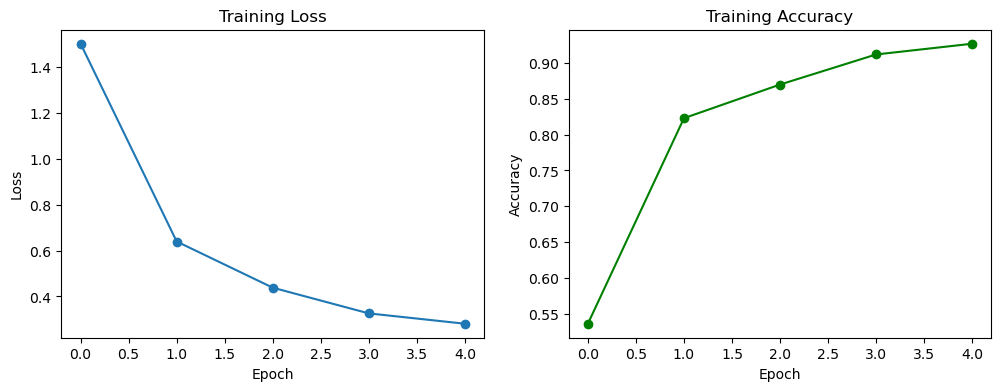

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["loss"], marker='o')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(history["acc"], marker='o', color='green')
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")

plt.show()

## Key Takeaways
- Even on a tiny subset, the model rapidly learns to minimize loss and increase accuracy.
- The production model was trained on all 60,000 images for many epochs to achieve ~98% accuracy.

## Interview Questions
- **What is Backpropagation?** It is an algorithm that uses the calculus chain rule to compute the gradient of the loss function with respect to every weight in the network.
- **What is Gradient Descent?** An optimization algorithm that takes steps proportional to the negative of the gradient to find the local minimum of a function (the lowest loss).